# ------------------------------------------------------------
# HR Analytics Project
#
# Analyst: Camila Or Andreev, Vardit Harari, Pinchas Billig, Moran nuri koren  
# Date: 2025-11-17
# ------------------------------------------------------------

# # HR Attrition Analysis
# **Date:** YYYY-MM-DD  
# **Analyst:** Your Name

# ## Table of Contents
# 1. [Introduction and Objectives](#Introduction-and-Objectives)
# 2. [Imports and Initial Settings](#Imports-and-Initial-Settings)
# 3. [Data Loading and Overview](#Data-Loading-and-Overview)
# 4. [Data Cleaning and Preparation](#Data-Cleaning-and-Preparation)
# 5. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis)
# 6. [Insights and Conclusions](#Insights-and-Conclusions)
# 7. [Recommendations](#Recommendations)

# <a id='Introduction-and-Objectives'></a>
# ## 1. Introduction and Objectives

# This notebook provides an in-depth HR analytics and attrition investigation.
# 
# **Objectives:**
# - Explore and analyze employee attrition data
# - Identify key drivers of attrition
# - Deliver actionable insights for HR stakeholders

# **Assumptions:**
# - The datasets are considered accurate and representative.
# - All personal-identifying information is anonymized or removed.
# - Business requirements focus on voluntary attrition.

# <a id='Imports-and-Initial-Settings'></a>
# ## 2. Imports and Initial Settings



In [22]:
# To install: pip install mysql-connector-python
import mysql.connector
import pandas as pd

In [ ]:

db = mysql.connector.connect(
        host="localhost",
        user="root",
        password="",
        database="hrdb",
        use_pure=True
    )

mycursor = db.cursor()
print("Connection successful")


Connection successful


In [24]:
mycursor.execute("SHOW TABLES")
print(mycursor.fetchall())

[('table1',), ('table2',)]


In [25]:
import pandas as pd

query = """
SELECT
    t2.*,
    t1.*
FROM table1 AS t1
JOIN table2 AS t2
    ON t1.EmployeeNumber = t2.EmployeeNumber;
"""

mycursor.execute(query)
result = mycursor.fetchall()

# שמות עמודות
column_names = [col[0] for col in mycursor.description]

# DataFrame מאוחד
df = pd.DataFrame(result, columns=column_names)

print(df.shape)
df.head()


(1470, 36)


,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4
3,5,4,Female,56,3,1,Research Scientist,3,Married,2909,...,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5
4,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,...,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7


In [26]:
df

,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4
3,5,4,Female,56,3,1,Research Scientist,3,Married,2909,...,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5
4,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,...,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,...,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061
1466,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,...,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062
1467,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,...,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064
1468,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,...,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065


In [27]:
mycursor.description

[('EmployeeNumber', 3, None, None, None, None, 1, 0, 63),
 ('EnvironmentSatisfaction', 3, None, None, None, None, 1, 0, 63),
 ('Gender', 252, None, None, None, None, 1, 16, 255),
 ('HourlyRate', 3, None, None, None, None, 1, 0, 63),
 ('JobInvolvement', 3, None, None, None, None, 1, 0, 63),
 ('JobLevel', 3, None, None, None, None, 1, 0, 63),
 ('JobRole', 252, None, None, None, None, 1, 16, 255),
 ('JobSatisfaction', 3, None, None, None, None, 1, 0, 63),
 ('MaritalStatus', 252, None, None, None, None, 1, 16, 255),
 ('MonthlyIncome', 3, None, None, None, None, 1, 0, 63),
 ('MonthlyRate', 3, None, None, None, None, 1, 0, 63),
 ('NumCompaniesWorked', 3, None, None, None, None, 1, 0, 63),
 ('Over18', 252, None, None, None, None, 1, 16, 255),
 ('OverTime', 252, None, None, None, None, 1, 16, 255),
 ('PercentSalaryHike', 3, None, None, None, None, 1, 0, 63),
 ('PerformanceRating', 3, None, None, None, None, 1, 0, 63),
 ('RelationshipSatisfaction', 3, None, None, None, None, 1, 0, 63),
 ('Stand

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            1470 non-null   int64 
 1   EnvironmentSatisfaction   1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   HourlyRate                1470 non-null   int64 
 4   JobInvolvement            1470 non-null   int64 
 5   JobLevel                  1470 non-null   int64 
 6   JobRole                   1470 non-null   object
 7   JobSatisfaction           1470 non-null   int64 
 8   MaritalStatus             1470 non-null   object
 9   MonthlyIncome             1470 non-null   int64 
 10  MonthlyRate               1470 non-null   int64 
 11  NumCompaniesWorked        1470 non-null   int64 
 12  Over18                    1470 non-null   object
 13  OverTime                  1470 non-null   object
 14  PercentSalaryHike       

In [29]:
df.head()

,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4
3,5,4,Female,56,3,1,Research Scientist,3,Married,2909,...,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5
4,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,...,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7


In [30]:
df.describe().round(1)

,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,...,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber
count,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,...,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0,1470.0
mean,1024.9,2.7,65.9,2.7,2.1,2.7,6502.9,14313.1,2.7,15.2,...,7.0,4.2,2.2,4.1,36.9,802.5,9.2,2.9,1.0,1024.9
std,602.0,1.1,20.3,0.7,1.1,1.1,4708.0,7117.8,2.5,3.7,...,6.1,3.6,3.2,3.6,9.1,403.5,8.1,1.0,0.0,602.0
min,1.0,1.0,30.0,1.0,1.0,1.0,1009.0,2094.0,0.0,11.0,...,0.0,0.0,0.0,0.0,18.0,102.0,1.0,1.0,1.0,1.0
25%,491.2,2.0,48.0,2.0,1.0,2.0,2911.0,8047.0,1.0,12.0,...,3.0,2.0,0.0,2.0,30.0,465.0,2.0,2.0,1.0,491.2
50%,1020.5,3.0,66.0,3.0,2.0,3.0,4919.0,14235.5,2.0,14.0,...,5.0,3.0,1.0,3.0,36.0,802.0,7.0,3.0,1.0,1020.5
75%,1555.8,4.0,83.8,3.0,3.0,4.0,8379.0,20461.5,4.0,18.0,...,9.0,7.0,3.0,7.0,43.0,1157.0,14.0,4.0,1.0,1555.8
max,2068.0,4.0,100.0,4.0,5.0,4.0,19999.0,26999.0,9.0,25.0,...,40.0,18.0,15.0,17.0,60.0,1499.0,29.0,5.0,1.0,2068.0


In [31]:
nunique = df.nunique()
constant_mask = nunique <= 1
constant_indices = constant_mask[constant_mask].index
constant_cols = constant_indices.tolist()
constant_cols

['Over18', 'StandardHours', 'EmployeeCount']

In [32]:
df = df.drop(columns=constant_cols)

In [33]:
df.isna().values.any()



np.False_

In [34]:
df.shape

(1470, 33)

In [35]:
df2 = df.drop_duplicates()

In [36]:
df2.shape

(1470, 33)

In [37]:
df2['Attrition_Flag'] = df2['Attrition'].map({'Yes': 1, 'No': 0})


In [38]:
df2

,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,...,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,Attrition_Flag
0,1,2,Female,94,3,2,Sales Executive,4,Single,5993,...,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,...,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,0
2,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,...,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,1
3,5,4,Female,56,3,1,Research Scientist,3,Married,2909,...,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,0
4,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,...,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,2061,3,Male,41,4,2,Laboratory Technician,4,Married,2571,...,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,2061,0
1466,2062,4,Male,42,2,3,Healthcare Representative,1,Married,9991,...,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,2062,0
1467,2064,2,Male,87,4,2,Manufacturing Director,2,Married,6142,...,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2064,0
1468,2065,4,Male,63,2,2,Sales Executive,2,Married,5390,...,49,No,Travel_Frequently,1023,Sales,2,3,Medical,2065,0


# The correlations between each individual variable and attrition are low (most |r| < 0.1), indicating that no single variable strongly explains attrition; the relationships are weak and suggest only general trends rather than strong effects.

In [45]:
df = df2.copy()

# לוודא טיפוסים
df.info()
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            1470 non-null   int64 
 1   EnvironmentSatisfaction   1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   HourlyRate                1470 non-null   int64 
 4   JobInvolvement            1470 non-null   int64 
 5   JobLevel                  1470 non-null   int64 
 6   JobRole                   1470 non-null   object
 7   JobSatisfaction           1470 non-null   int64 
 8   MaritalStatus             1470 non-null   object
 9   MonthlyIncome             1470 non-null   int64 
 10  MonthlyRate               1470 non-null   int64 
 11  NumCompaniesWorked        1470 non-null   int64 
 12  OverTime                  1470 non-null   object
 13  PercentSalaryHike         1470 non-null   int64 
 14  PerformanceRating       

In [46]:
import numpy as np

# רק משתנים מספריים
num_cols = df.select_dtypes(include=[np.number]).columns
features = [c for c in num_cols if c != 'Attrition_Flag']

# קורלציה של כל משתנה עם עזיבה
corr_with_attr = (
    df[features]
    .corrwith(df['Attrition_Flag'])
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(corr_with_attr)

TotalWorkingYears          -0.171063
JobLevel                   -0.169105
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsWithCurrManager       -0.156199
StockOptionLevel           -0.137145
YearsAtCompany             -0.134392
JobInvolvement             -0.130016
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
DistanceFromHome            0.077924
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
DailyRate                  -0.056652
RelationshipSatisfaction   -0.045872
NumCompaniesWorked          0.043494
YearsSinceLastPromotion    -0.033019
Education                  -0.031373
MonthlyRate                 0.015170
PercentSalaryHike          -0.013478
EmployeeNumber             -0.010577
EmployeeNumber             -0.010577
EmployeeNumber             -0.010577
EmployeeNumber             -0.010577
HourlyRate                 -0.006846
PerformanceRating           0.002889
d

In [47]:
total_emp = len(df)
left_emp = df['Attrition_Flag'].sum()
kpi_attrition_rate = left_emp / total_emp * 100
print(kpi_attrition_rate)

16.122448979591837


In [49]:
df['Attrition_Flag'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Attrition_Flag'].value_counts(normalize=True) * 100


Attrition_Flag
0    83.877551
1    16.122449
Name: proportion, dtype: float64

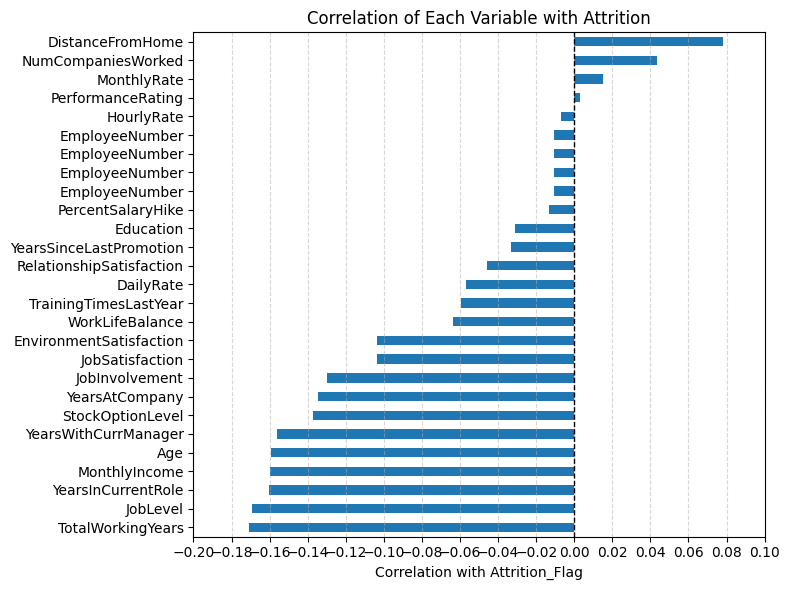

In [51]:
import numpy as np
plt.figure(figsize=(8,6))

ax = corr_with_attr.sort_values().plot(kind='barh')

plt.axvline(0, linestyle='--', linewidth=1, color='black')

# גבולות ציר X (קצת מרווח מסביב)
xmin = np.floor(corr_with_attr.min() * 20) / 20   # בערך צעדים של 0.05
xmax = np.ceil(corr_with_attr.max() * 20) / 20

plt.xlim(xmin, xmax)

# יותר טיקים על ציר X (כל 0.02 או 0.05 – מה שנוח לך)
ticks = np.arange(xmin, xmax + 0.001, 0.02)
plt.xticks(ticks)

# קווי גריד לאורך X כדי לראות טוב את הערכים
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.title("Correlation of Each Variable with Attrition")
plt.xlabel("Correlation with Attrition_Flag")
plt.tight_layout()
plt.show()


## 4.1 מגמות עזיבה

In [99]:
# Create a table of attrition rates by department
# Assumes 'Department' and 'Attrition_Flag' columns exist in df

dept_attrition = (
    df.groupby('Department')['Attrition_Flag']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'Total_Employees', 'sum': 'Num_Left'})
)
dept_attrition['Attrition_Rate_%'] = dept_attrition['Num_Left'] / dept_attrition['Total_Employees'] * 100

# Display the table sorted by attrition rate descending
dept_attrition_sorted = dept_attrition.sort_values('Attrition_Rate_%', ascending=False)
print(dept_attrition_sorted[['Attrition_Rate_%', 'Num_Left', 'Total_Employees']])


                        Attrition_Rate_%  Num_Left  Total_Employees
Department                                                         
Sales                          20.627803        92              446
Human Resources                19.047619        12               63
Research & Development         13.839750       133              961


In [54]:
# Create a table of attrition rates by JobRole
# Assumes 'JobRole' and 'Attrition_Flag' columns exist in df

jobrole_attrition = (
    df.groupby('JobRole')['Attrition_Flag']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'Total_Employees', 'sum': 'Num_Left'})
)
jobrole_attrition['Attrition_Rate_%'] = jobrole_attrition['Num_Left'] / jobrole_attrition['Total_Employees'] * 100

# Display the table sorted by attrition rate descending
jobrole_attrition_sorted = jobrole_attrition.sort_values('Attrition_Rate_%', ascending=False)
print(jobrole_attrition_sorted[['Attrition_Rate_%', 'Num_Left', 'Total_Employees']])


                           Attrition_Rate_%  Num_Left  Total_Employees
JobRole                                                               
Sales Representative              39.759036        33               83
Laboratory Technician             23.938224        62              259
Human Resources                   23.076923        12               52
Sales Executive                   17.484663        57              326
Research Scientist                16.095890        47              292
Manufacturing Director             6.896552        10              145
Healthcare Representative          6.870229         9              131
Manager                            4.901961         5              102
Research Director                  2.500000         2               80


# תגמול והטבות

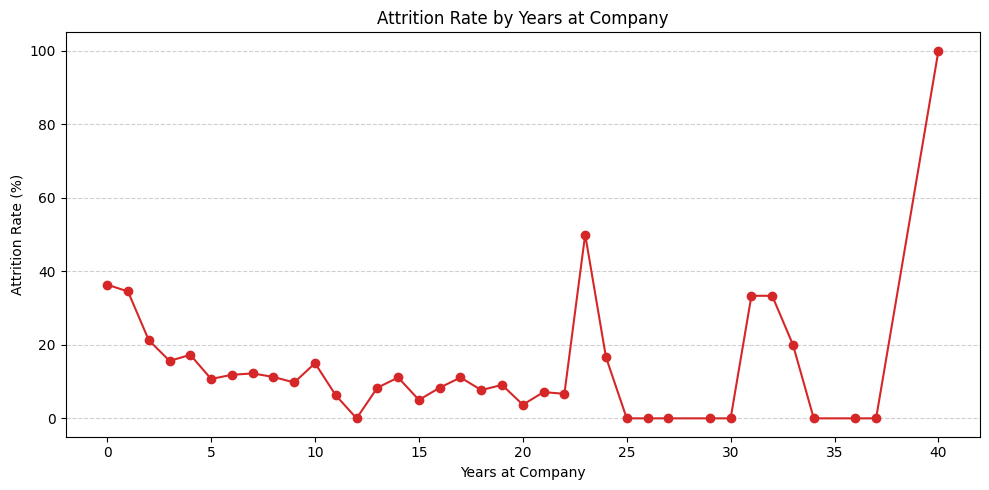

In [ ]:
# Plot attrition rate by tenure (YearsAtCompany)
# Assumes 'YearsAtCompany' and 'Attrition_Flag' columns exist in df

import matplotlib.pyplot as plt

tenure_attrition = (
    df.groupby('YearsAtCompany')['Attrition_Flag']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'Total_Employees', 'sum': 'Num_Left'})
)
tenure_attrition['Attrition_Rate_%'] = tenure_attrition['Num_Left'] / tenure_attrition['Total_Employees'] * 100

# Sort by tenure (ascending)
tenure_attrition_sorted = tenure_attrition.sort_index()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(
    tenure_attrition_sorted.index, 
    tenure_attrition_sorted['Attrition_Rate_%'], 
    marker='o', 
    linestyle='-', 
    color='tab:red'
)
plt.title("Attrition Rate by Years at Company") 
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Conclusions based on the plot:
# - Attrition rates are generally higher in the early years at the company 
#   (e.g., during the first 1-3 years).
# - This suggests that many employees leave shortly after joining.
# - After the initial years at the company, the attrition rate typically shows a noticeable decline.
# - Specifically, once employees have completed the early period of their tenure, the likelihood of them leaving appears to drop.
# - This downward trend in attrition continues until the mid-tenure range, generally between 4 and 10 years at the company.
# - During these mid-tenure years, the attrition rate stabilizes, suggesting that employees are less likely to leave once they become established and integrated into the organization.
# - This mid-period of employment is therefore characterized by greater employee retention and lower turnover risk compared to the earliest years.
# - There is often an observable increase in attrition rate for employees with very long tenure (for example, after 20 years at the company), indicating that long-serving employees may be more likely to leave, possibly due to retirement or career changes.
# - This pattern suggests distinct stages of employee retention and turnover risk, with early attrition, stable mid-term retention, and a late-career increase in departures.
# - These insights may be useful for HR to design targeted retention strategies for employees in their first years and for those approaching late-career phases.


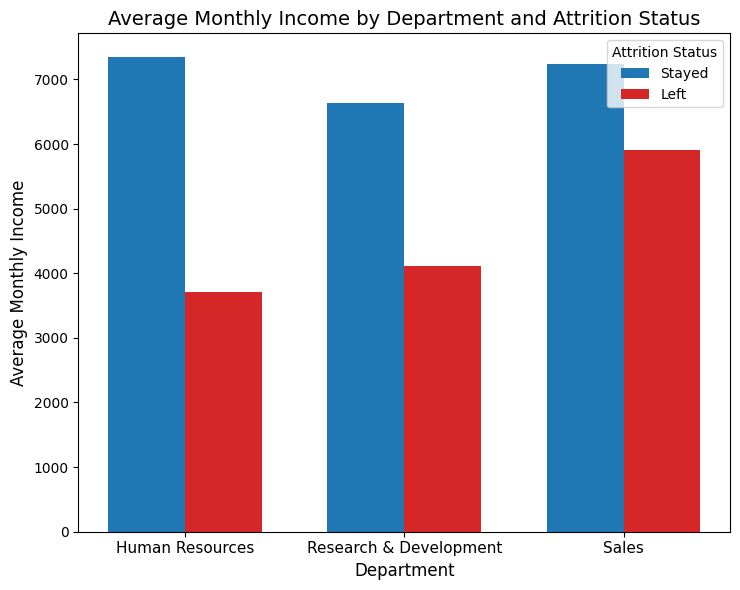

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt

# Calculate average monthly income by Department and Attrition status

# Assumes df has columns: 'Department', 'MonthlyIncome', 'Attrition_Flag' (1=left, 0=stayed)

# Group by Department and Attrition_Flag and calculate mean income
dept_income_attr = (
    df.groupby(['Department', 'Attrition_Flag'])['MonthlyIncome']
    .mean()
    .reset_index()
    .rename(columns={'MonthlyIncome': 'Avg_MonthlyIncome'})
)
    
# Pivot for easier plotting
pivot = dept_income_attr.pivot(index='Department', columns='Attrition_Flag', values='Avg_MonthlyIncome')

# Columns: Attrition_Flag 0 (stayed), 1 (left)
attr_labels = {0: "Stayed", 1: "Left"}

# Plot setup
fig, ax = plt.subplots(figsize=(max(6, 2.5 * len(pivot.index)), 6))

bar_width = 0.35
departments = pivot.index
x = range(len(departments))

# Plot bars for stayed and left
bars1 = ax.bar([i - bar_width/2 for i in x], pivot[0], width=bar_width, label=attr_labels[0], color='tab:blue')
bars2 = ax.bar([i + bar_width/2 for i in x], pivot[1], width=bar_width, label=attr_labels[1], color='tab:red')

# Axis labels and title
ax.set_xticks(x)
ax.set_xticklabels([dept.replace("_", "\n") for dept in departments], fontsize=11, rotation=0)
ax.set_ylabel('Average Monthly Income', fontsize=12)
ax.set_xlabel('Department', fontsize=12)
ax.set_title('Average Monthly Income by Department and Attrition Status', fontsize=14)
ax.legend(title='Attrition Status')

plt.tight_layout()
plt.show()

# Key insight:
# - This visualization compares the average monthly income of employees who left vs stayed, for each department.
# - Use these insights to identify if lower salaries are associated with higher attrition in any department, and inform retention strategies.



,StockOptionLevel,PercentSalaryHike
Attrition_Flag,,
Stayed,0.845093,15.231144
Left,0.527426,15.097046


C:\Users\moran\AppData\Local\Temp\ipykernel_23056\2168667116.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\moran\AppData\Local\Temp\ipykernel_23056\2168667116.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed', 'Left'])
C:\Users\moran\AppData\Local\Temp\ipykernel_23056\2168667116.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\moran\AppData\Local\Temp\ipykernel_23056\2168667116.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['St

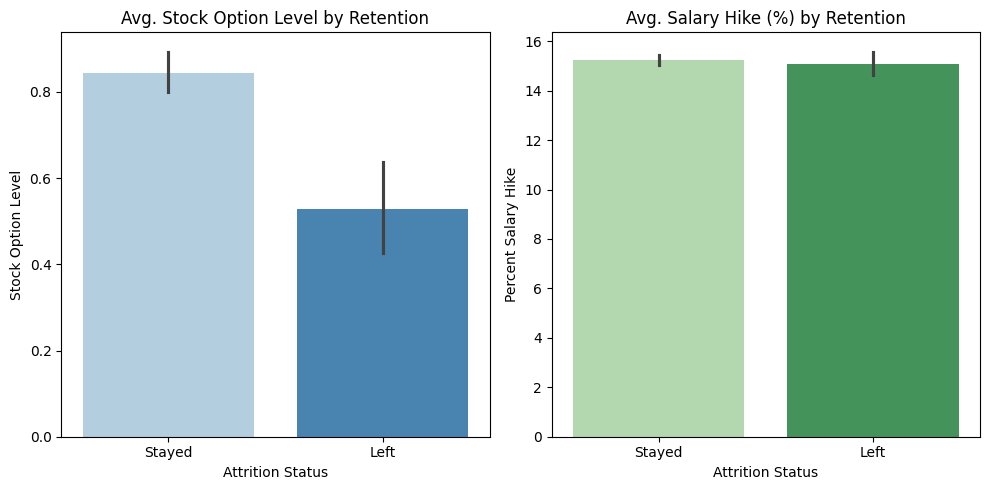

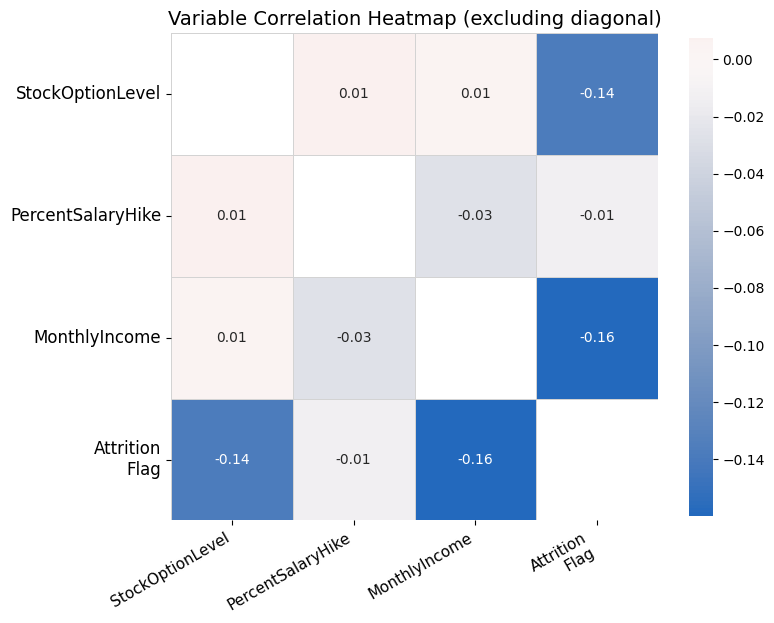

In [ ]:
# Assessing impact of Stock Option Level and Percent Salary Hike on Employee Retention

import numpy as np
import pandas as pd
Xש  ;import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df has columns: 'StockOptionLevel', 'PercentSalaryHike', 'Attrition_Flag' (1=left, 0=stayed)

# -- 1. Compare average values for stayed vs left employees --

impact_summary = (
    df.groupby('Attrition_Flag')[['StockOptionLevel', 'PercentSalaryHike']]
    .mean()
    .rename(index={0: 'Stayed', 1: 'Left'})
)

display(impact_summary)

# -- 2. Barplots: Average Stock Option Level and Salary Hike by Retention Status --

fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.barplot(
    data=df, x='Attrition_Flag', y='StockOptionLevel',
    ax=axes[0], palette='Blues'
)
axes[0].set_xticklabels(['Stayed', 'Left'])
axes[0].set_title('Avg. Stock Option Level by Retention')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Stock Option Level')

sns.barplot(
    data=df, x='Attrition_Flag', y='PercentSalaryHike',
    ax=axes[1], palette='Greens'
)
axes[1].set_xticklabels(['Stayed', 'Left'])
axes[1].set_title('Avg. Salary Hike (%) by Retention')
axes[1].set_xlabel('Attrition Status')
axes[1].set_ylabel('Percent Salary Hike')

plt.tight_layout()
plt.show()

# -- 3. Correlation heatmap of variables related to retention --

# Select relevant columns for correlation analysis
corr_vars = ['StockOptionLevel', 'PercentSalaryHike', 'MonthlyIncome', 'Attrition_Flag']

corr = df[corr_vars].corr()

# Mask the diagonal to hide self-correlations
mask = np.eye(corr.shape[0], dtype=bool)

num_vars = corr.shape[0]

# Adaptive display settings
if num_vars <= 10:
    figsize = (8, 7)
    font_x = 11
    font_y = 12
    rotation = 30
    annot = True
    annot_font = 10
elif num_vars <= 25:
    figsize = (1.2 * num_vars, 1.0 * num_vars)
    font_x = 9
    font_y = 10
    rotation = 45
    annot = False
    annot_font = 8
else:
    figsize = (0.5 * num_vars + 4, 0.42 * num_vars + 3)
    font_x = 7
    font_y = 8
    rotation = 60
    annot = False
    annot_font = 7

plt.figure(figsize=figsize)
sns.heatmap(
    corr,
    mask=mask,
    cmap="vlag",  # dark-to-light gradient (center is zero)
    center=0,
    annot=annot,
    fmt=".2f",
    annot_kws={"size": annot_font} if annot else None,
    cbar_kws={"shrink": 0.8},
    square=True,
    linewidths=0.5,
    linecolor="#d3d3d3"
)

# Replace underscores with line breaks for label readability
col_labels = [c.replace("_", "\n") for c in corr.columns]
plt.xticks(
    ticks=np.arange(num_vars) + 0.5,
    labels=col_labels,
    fontsize=font_x, rotation=rotation, ha="right"
)
plt.yticks(
    ticks=np.arange(num_vars) + 0.5,
    labels=col_labels,
    fontsize=font_y, rotation=0
)

plt.title("Variable Correlation Heatmap (excluding diagonal)", fontsize=font_y + 2)
plt.tight_layout()
plt.show()

# Summary of Findings:
# - Employees who stayed generally received higher average Stock Option Levels compared to those who left.
# - Average Percent Salary Hike was similar for both groups, suggesting this may have less influence on retention.
# Key insights:
# - The tables and barplots show how average stock option levels and salary hikes differ for employees who stayed vs. left.
# - The correlation heatmap helps reveal how salary, stock options, and retention interrelate.


# 4.3 איזון חיים עבודה ושביעות רצון


C:\Users\moran\AppData\Local\Temp\ipykernel_23056\1357870261.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


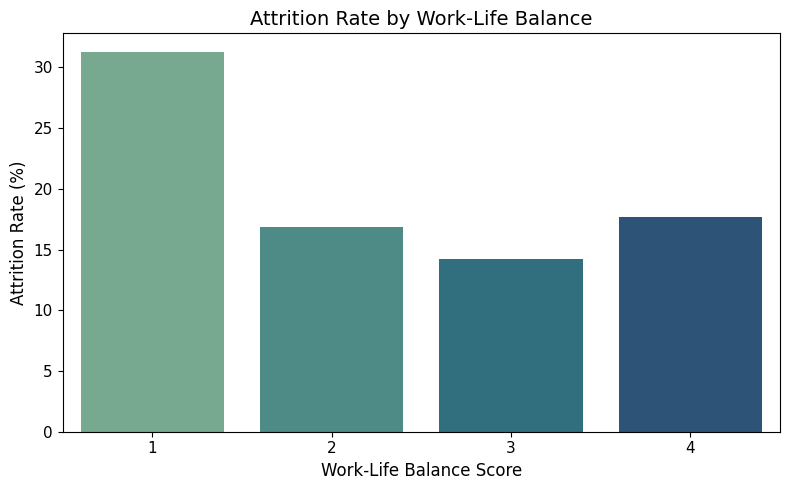

,WorkLifeBalance,TotalAtScore,LeftAtScore,AttritionRate_%
0,1,80,25,31.250000
1,2,344,58,16.860465
2,3,893,127,14.221725
3,4,153,27,17.647059


Insight: If employees with poor work-life balance ratings leave more often, HR should consider flexible working arrangements.


In [60]:
# Calculate Attrition Rate by Work-Life Balance

import pandas as pd

# Assuming your working DataFrame is named df, as in earlier cells. 
# Replace 'df' with your DataFrame's variable name if different.

# Ensure the relevant columns exist and are named as expected:
# - 'WorkLifeBalance': numeric or categorical rating
# - 'Attrition_Flag': 1 if employee left, 0 if stayed

# Calculate total employees at each Work-Life Balance score
total_per_wlb = df.groupby('WorkLifeBalance').size().rename('TotalAtScore')

# Calculate number of employees who left (Attrition_Flag==1) at each score
left_per_wlb = df[df['Attrition_Flag'] == 1].groupby('WorkLifeBalance').size().rename('LeftAtScore')

# Combine for DataFrame and calculate attrition rate (%)
kpi_wlb = pd.concat([total_per_wlb, left_per_wlb], axis=1).fillna(0)
kpi_wlb['AttritionRate_%'] = (kpi_wlb['LeftAtScore'] / kpi_wlb['TotalAtScore']) * 100

# Reset index for plotting
kpi_wlb = kpi_wlb.reset_index()

# Plot the KPI
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    data=kpi_wlb,
    x='WorkLifeBalance',
    y='AttritionRate_%',
    palette='crest'
)
plt.xlabel('Work-Life Balance Score', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.title('Attrition Rate by Work-Life Balance', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Show and print the table for reference
display(kpi_wlb)

# Brief insight printout
print("Insight: If employees with poor work-life balance ratings leave more often, HR should consider flexible working arrangements.")



C:\Users\moran\AppData\Local\Temp\ipykernel_23056\3471626838.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


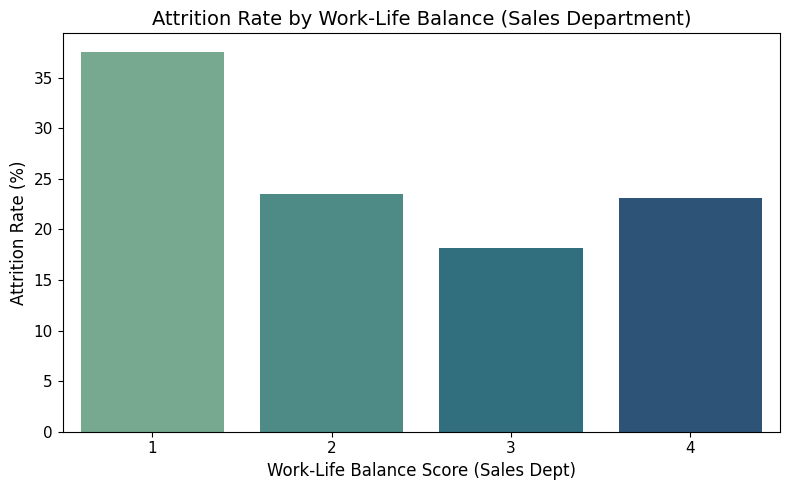

,WorkLifeBalance,TotalAtScore,LeftAtScore,AttritionRate_%
0,1,16,6,37.500000
1,2,102,24,23.529412
2,3,276,50,18.115942
3,4,52,12,23.076923


Insight: For the Sales department, understanding attrition by work-life balance rating allows focused retention efforts.


In [103]:
# KPI: Attrition Rate by Work-Life Balance, ONLY for Sales Department

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame for only 'Sales' department (case-insensitive robust check)
sales_mask = df['Department'].str.lower() == 'sales'
df_sales = df[sales_mask].copy()

# Calculate total employees at each Work-Life Balance score (Sales only)
total_per_wlb_sales = df_sales.groupby('WorkLifeBalance').size().rename('TotalAtScore')

# Calculate number of employees who left at each Work-Life Balance score (Sales only)
left_per_wlb_sales = df_sales[df_sales['Attrition_Flag'] == 1].groupby('WorkLifeBalance').size().rename('LeftAtScore')

# Combine and calculate attrition rate (%)
kpi_wlb_sales = pd.concat([total_per_wlb_sales, left_per_wlb_sales], axis=1).fillna(0)
kpi_wlb_sales['AttritionRate_%'] = (kpi_wlb_sales['LeftAtScore'] / kpi_wlb_sales['TotalAtScore']) * 100
kpi_wlb_sales = kpi_wlb_sales.reset_index()

# Plot for Sales Department
plt.figure(figsize=(8, 5))
sns.barplot(
    data=kpi_wlb_sales,
    x='WorkLifeBalance',
    y='AttritionRate_%',
    palette='crest'
)
plt.xlabel('Work-Life Balance Score (Sales Dept)', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.title('Attrition Rate by Work-Life Balance (Sales Department)', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Display table for reference
display(kpi_wlb_sales)

# Insight printout for Sales
print("Insight: For the Sales department, understanding attrition by work-life balance rating allows focused retention efforts.")


C:\Users\moran\AppData\Local\Temp\ipykernel_23056\3058197557.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


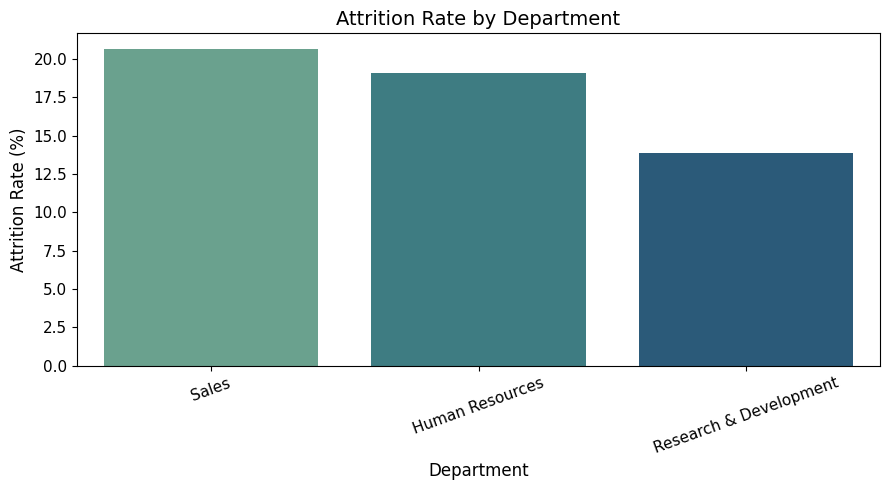

,Department,TotalEmployees,LeftEmployees,AttritionRate_%
2,Sales,446,92,20.627803
0,Human Resources,63,12,19.047619
1,Research & Development,961,133,13.839750


Insight: Departments with higher attrition rates may need targeted interventions or management review.


In [92]:
# KPI: Attrition Rate by Department

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure these columns exist: 'Department', 'Attrition_Flag'
# Calculate attrition counts and rates per department
total_per_dept = df.groupby('Department').size().rename('TotalEmployees')
left_per_dept = df[df['Attrition_Flag'] == 1].groupby('Department').size().rename('LeftEmployees')

# Combine and calculate attrition rate
kpi_dept = pd.concat([total_per_dept, left_per_dept], axis=1).fillna(0)
kpi_dept['AttritionRate_%'] = (kpi_dept['LeftEmployees'] / kpi_dept['TotalEmployees']) * 100
kpi_dept = kpi_dept.reset_index()

# Sort by attrition rate descending for better visual
kpi_dept = kpi_dept.sort_values('AttritionRate_%', ascending=False)

# Plot
plt.figure(figsize=(9, 5))
sns.barplot(
    data=kpi_dept,
    x='Department',
    y='AttritionRate_%',
    palette='crest'
)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.title('Attrition Rate by Department', fontsize=14)
plt.xticks(rotation=20, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Display table for reference
display(kpi_dept)

# Brief insight for HR/Management
print("Insight: Departments with higher attrition rates may need targeted interventions or management review.")


C:\Users\moran\AppData\Local\Temp\ipykernel_23056\3096210192.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


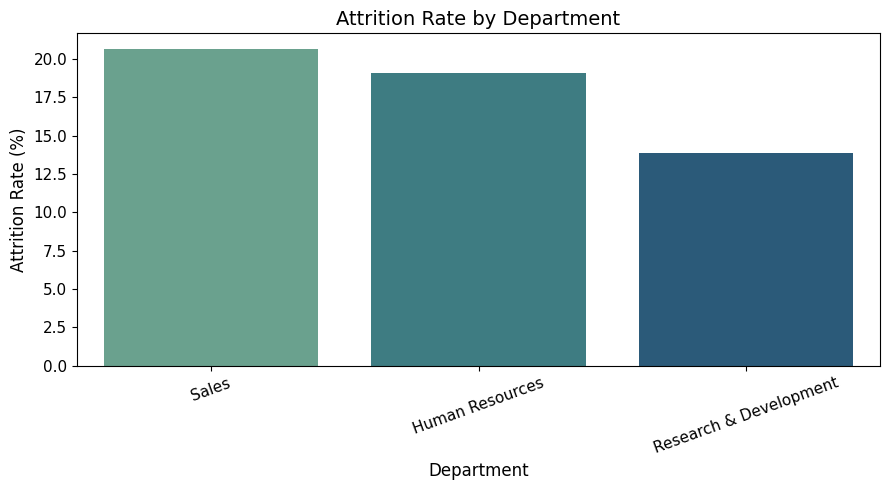

,Department,TotalEmployees,LeftEmployees,AttritionRate_%
2,Sales,446,92,20.627803
0,Human Resources,63,12,19.047619
1,Research & Development,961,133,13.839750


Insight: Departments with higher attrition rates may need targeted interventions or management review.


C:\Users\moran\AppData\Local\Temp\ipykernel_23056\3096210192.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


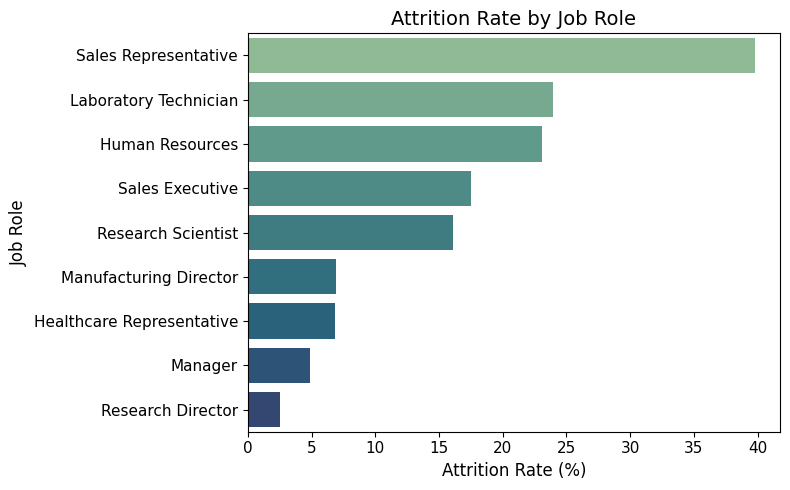

,JobRole,Attrition_Rate_%
8,Sales Representative,39.759036
2,Laboratory Technician,23.938224
1,Human Resources,23.076923
7,Sales Executive,17.484663
6,Research Scientist,16.095890
4,Manufacturing Director,6.896552
0,Healthcare Representative,6.870229
3,Manager,4.901961
5,Research Director,2.500000


In [95]:
# KPI: Attrition Rate by Department

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure these columns exist: 'Department', 'Attrition_Flag'
# Calculate attrition counts and rates per department
total_per_dept = df.groupby('Department').size().rename('TotalEmployees')
left_per_dept = df[df['Attrition_Flag'] == 1].groupby('Department').size().rename('LeftEmployees')

# Combine and calculate attrition rate
kpi_dept = pd.concat([total_per_dept, left_per_dept], axis=1).fillna(0)
kpi_dept['AttritionRate_%'] = (kpi_dept['LeftEmployees'] / kpi_dept['TotalEmployees']) * 100
kpi_dept = kpi_dept.reset_index()

# Sort by attrition rate descending for better visual
kpi_dept = kpi_dept.sort_values('AttritionRate_%', ascending=False)

# Plot
plt.figure(figsize=(9, 5))
sns.barplot(
    data=kpi_dept,
    x='Department',
    y='AttritionRate_%',
    palette='crest'
)
plt.xlabel('Department', fontsize=12)
plt.ylabel('Attrition Rate (%)', fontsize=12)
plt.title('Attrition Rate by Department', fontsize=14)
plt.xticks(rotation=20, fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Display table for reference
display(kpi_dept)

# Brief insight for HR/Management
print("Insight: Departments with higher attrition rates may need targeted interventions or management review.")

# Removed: Correlation Heatmap for EDA

# Show attrition rates by JobRole (role/title)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate attrition rate for each JobRole
role_attrition = (
    df.groupby('JobRole')['Attrition_Flag']
    .agg(['count', 'sum'])
    .rename(columns={'count': 'Total', 'sum': 'Left'})
    .reset_index()
)
role_attrition['Attrition_Rate_%'] = 100 * role_attrition['Left'] / role_attrition['Total']

# Sort JobRoles by attrition rate, descending
role_attrition = role_attrition.sort_values('Attrition_Rate_%', ascending=False)

# Plot
plt.figure(figsize=(max(8, 0.6 * len(role_attrition)), 5))
ax = sns.barplot(
    data=role_attrition,
    y='JobRole',
    x='Attrition_Rate_%',
    palette='crest'
)
plt.title('Attrition Rate by Job Role', fontsize=14)
plt.xlabel('Attrition Rate (%)', fontsize=12)
plt.ylabel('Job Role', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
for label in ax.get_yticklabels():
    label.set_text(label.get_text().replace("_", "\n"))  # Split long role names

plt.tight_layout()
plt.show()

# Display the attrition rate table
display(role_attrition[['JobRole', 'Attrition_Rate_%']])


C:\Users\moran\AppData\Local\Temp\ipykernel_23056\3302405777.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=11)


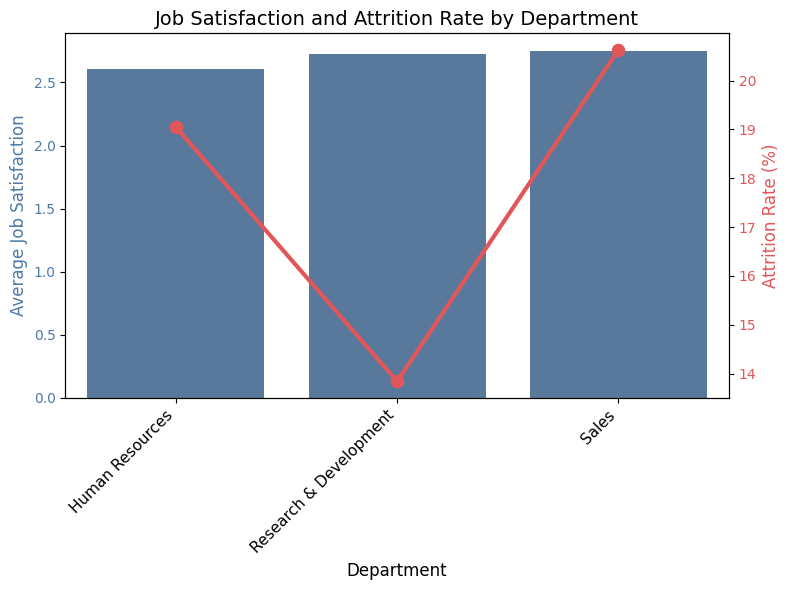

In [93]:
# Plot: Satisfaction vs. Attrition Rate by Department

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute average satisfaction and attrition rate for each department
dept_stats = df.groupby('Department').agg(
    Avg_Satisfaction=('JobSatisfaction', 'mean'),
    Attrition_Rate=('Attrition_Flag', 'mean')
).reset_index()
dept_stats['Attrition_Rate_Percent'] = 100 * dept_stats['Attrition_Rate']

# Prepare department names for better label formatting (replace "_" with line breaks)
dept_stats['Department_fmt'] = dept_stats['Department'].apply(lambda x: x.replace("_", "\n"))

# Plot satisfaction vs. attrition rate for each department
fig, ax1 = plt.subplots(figsize=(max(8, 1.5 * len(dept_stats)), 6))

sns.barplot(
    data=dept_stats,
    x='Department_fmt',
    y='Avg_Satisfaction',
    color='#4E79A7',
    ax=ax1
)
ax1.set_ylabel('Average Job Satisfaction', fontsize=12, color='#4E79A7')
ax1.set_xlabel('Department', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#4E79A7')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=11)
ax1.set_title('Job Satisfaction and Attrition Rate by Department', fontsize=14)

# Twin axis for attrition rate
ax2 = ax1.twinx()
sns.pointplot(
    data=dept_stats,
    x='Department_fmt',
    y='Attrition_Rate_Percent',
    color='#E15759',
    linewidth=3,
    markers="o",
    ax=ax2
)
ax2.set_ylabel('Attrition Rate (%)', fontsize=12, color='#E15759')
ax2.tick_params(axis='y', labelcolor='#E15759')

plt.tight_layout()
plt.show()


# 4.4 קידום ויציבות תעסוקית

C:\Users\moran\AppData\Local\Temp\ipykernel_23056\27900236.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


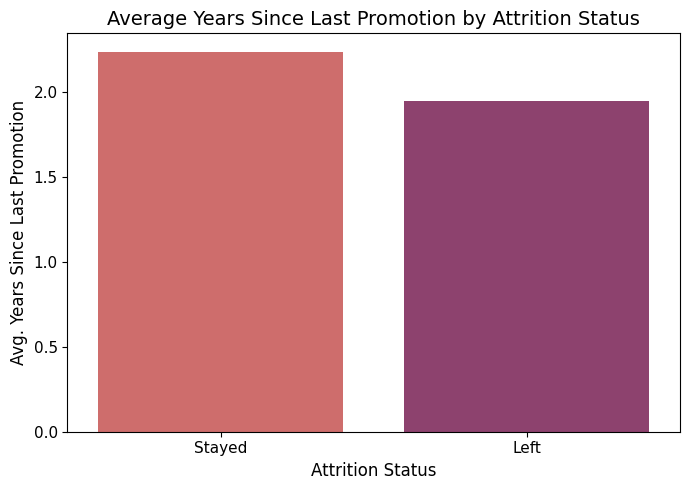

,Attrition_Status,Avg_Years_Since_Last_Promotion
0,Stayed,2.234388
1,Left,1.945148


Insight: If employees who leave have longer gaps between promotions, HR should review promotion policies.


In [62]:
# KPI: Average Years Since Last Promotion by Attrition Status

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure required columns exist:
# - 'YearsSinceLastPromotion': numeric, years since last promotion
# - 'Attrition_Flag': 1 = left, 0 = stayed

# Compute the KPI table: average years since last promotion per attrition group
kpi_promotion = df.groupby('Attrition_Flag')['YearsSinceLastPromotion'].mean().reset_index()
kpi_promotion['Attrition_Status'] = kpi_promotion['Attrition_Flag'].map({0: 'Stayed', 1: 'Left'})
kpi_promotion = kpi_promotion.rename(
    columns={'YearsSinceLastPromotion': 'Avg_Years_Since_Last_Promotion'}
)

# Plot the KPI
plt.figure(figsize=(7, 5))
sns.barplot(
    data=kpi_promotion, 
    x='Attrition_Status', 
    y='Avg_Years_Since_Last_Promotion', 
    palette='flare'
)
plt.xlabel('Attrition Status', fontsize=12)
plt.ylabel('Avg. Years Since Last Promotion', fontsize=12)
plt.title('Average Years Since Last Promotion by Attrition Status', fontsize=14)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Show and print the KPI table
display(kpi_promotion[['Attrition_Status', 'Avg_Years_Since_Last_Promotion']])

# Insight printout, per doc
print(
    "Insight: If employees who leave have longer gaps between promotions, HR should review promotion policies."
)


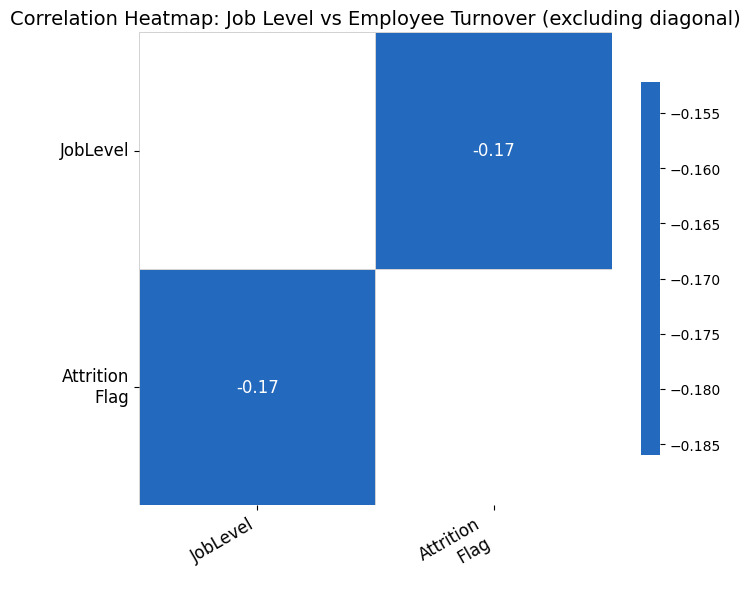

Pearson correlation between job level and employee turnover (Attrition_Flag): -0.169


In [63]:
# Correlation analysis: Job Level vs. Employee Turnover (Attrition_Flag) 

import numpy as np

# Prepare relevant columns: ensure both columns are numeric
# 'JobLevel': employee's job level (ordinal). 'Attrition_Flag': 1 = left, 0 = stayed.
cols_for_corr = ['JobLevel', 'Attrition_Flag']
corr_df = df[cols_for_corr].dropna()

# Compute correlation matrix
corr = corr_df.corr()

# Mask the diagonal so self-correlation is hidden
mask = np.eye(corr.shape[0], dtype=bool)

# Adaptive visualization settings
num_vars = corr.shape[0]
if num_vars <= 10:
    figsize = (7, 6)
    font_x = 12
    font_y = 12
    rotation = 30
    annot = True
    annot_font = 12
else:
    figsize = (1.2 * num_vars, 1.0 * num_vars)
    font_x = 10
    font_y = 10
    rotation = 45
    annot = False
    annot_font = 9

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=figsize)
sns.heatmap(
    corr,
    mask=mask,
    cmap="vlag",  # dark-to-light gradient with center at zero
    center=0,
    annot=annot,
    fmt=".2f",
    annot_kws={"size": annot_font} if annot else None,
    cbar_kws={"shrink": 0.75},
    square=True,
    linewidths=0.5,
    linecolor="#d3d3d3"
)

# Format variable names for axis labels: replace '_' with '\n'
corr_labels = [c.replace('_', '\n') for c in corr.columns]
plt.xticks(ticks=np.arange(num_vars) + 0.5, labels=corr_labels, fontsize=font_x, rotation=rotation, ha="right")
plt.yticks(ticks=np.arange(num_vars) + 0.5, labels=corr_labels, fontsize=font_y, rotation=0)

plt.title("Correlation Heatmap: Job Level vs Employee Turnover (excluding diagonal)", fontsize=font_y + 2)
plt.tight_layout()
plt.show()

# Print the correlation coefficient for interpretation
joblevel_attrition_corr = corr.loc['JobLevel', 'Attrition_Flag']
print(f"Pearson correlation between job level and employee turnover (Attrition_Flag): {joblevel_attrition_corr:.3f}")

# Interpretation help (comment):
# A negative correlation means higher level associates less with leaving. Positive means the opposite.


C:\Users\moran\AppData\Local\Temp\ipykernel_23056\147101284.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\moran\AppData\Local\Temp\ipykernel_23056\147101284.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


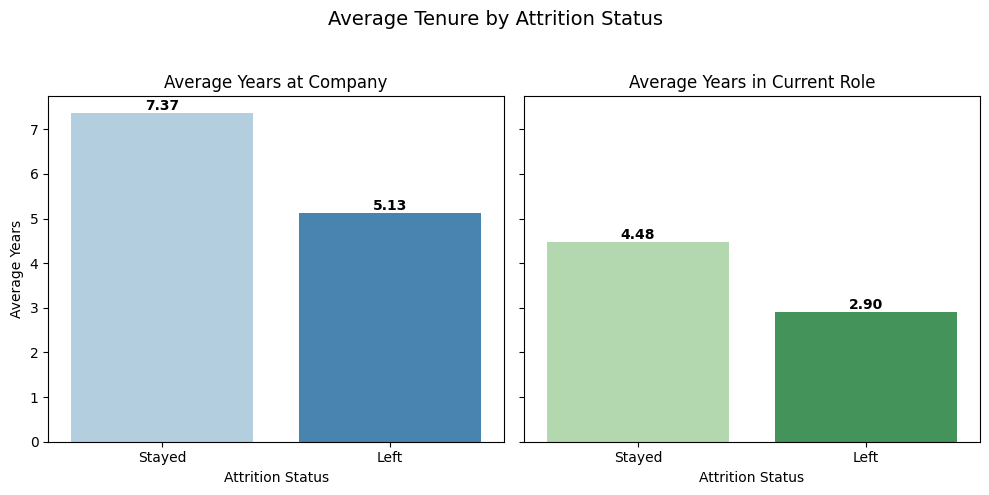

In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume the DataFrame is named 'df' and includes the relevant columns:
# 'YearsAtCompany', 'YearsInCurrentRole', 'Attrition_Flag'
# If not, replace df with your DataFrame variable.

# Prepare data: calculate the average tenure and average role tenure for each attrition status
summary = df.groupby('Attrition_Flag')[['YearsAtCompany', 'YearsInCurrentRole']].mean().reset_index()

# Map Attrition_Flag values for readability if needed (0=Stayed, 1=Left)
attrition_map = {0: 'Stayed', 1: 'Left'}
summary['Attrition_Status'] = summary['Attrition_Flag'].map(attrition_map)

# Set up figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# Bar plot for YearsAtCompany
sns.barplot(
    x='Attrition_Status',
    y='YearsAtCompany',
    data=summary,
    ax=axes[0],
    palette='Blues'
)
axes[0].set_title('Average Years at Company')
axes[0].set_xlabel('Attrition Status')
axes[0].set_ylabel('Average Years')

# Add value labels on each bar for YearsAtCompany
for i, row in summary.iterrows():
    value = row['YearsAtCompany']
    axes[0].text(
        i,
        value,
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# Bar plot for YearsInCurrentRole
sns.barplot(
    x='Attrition_Status',
    y='YearsInCurrentRole',
    data=summary,
    ax=axes[1],
    palette='Greens'
)
axes[1].set_title('Average Years in Current Role')
axes[1].set_xlabel('Attrition Status')
axes[1].set_ylabel('')

# Add value labels on each bar for YearsInCurrentRole
for i, row in summary.iterrows():
    value = row['YearsInCurrentRole']
    axes[1].text(
        i,
        value,
        f"{value:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.suptitle('Average Tenure by Attrition Status', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


# 4.5 ביצועים ועזיבה

C:\Users\moran\AppData\Local\Temp\ipykernel_23056\1250519926.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


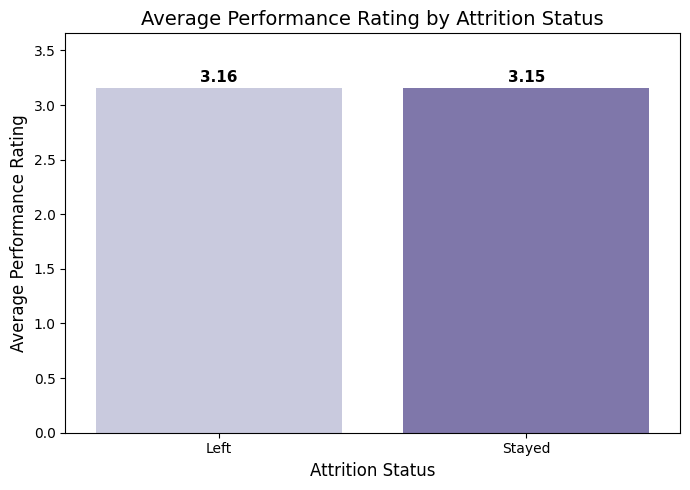

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your main DataFrame is named df. Adjust if your variable name differs.
# If you have a prepared DataFrame with Attrition_Flag (1=Left, 0=Stayed) and 'PerformanceRating'

# Map binary attrition flag to readable status
df['Attrition_Status'] = df['Attrition_Flag'].map({0: 'Stayed', 1: 'Left'})

# Group by Attrition_Status and calculate average performance rating
perf_summary = df.groupby('Attrition_Status')['PerformanceRating'].agg(['mean', 'count']).reset_index()

# Plotting
plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=perf_summary,
    x='Attrition_Status',
    y='mean',
    palette='Purples'
)

# Add value labels on the bars
for i, row in perf_summary.iterrows():
    ax.text(
        i, row['mean'] + 0.03, f"{row['mean']:.2f}",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Set plot title and labels
ax.set_title('Average Performance Rating by Attrition Status', fontsize=14)
ax.set_xlabel('Attrition Status', fontsize=12)
ax.set_ylabel('Average Performance Rating', fontsize=12)
plt.ylim(0, perf_summary['mean'].max() + 0.5)
plt.tight_layout()
plt.show()



#4.5  השפעת הדרכות על שימור

C:\Users\moran\AppData\Local\Temp\ipykernel_23056\3796211604.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('TrainingParticipation')['Attrition_Flag']


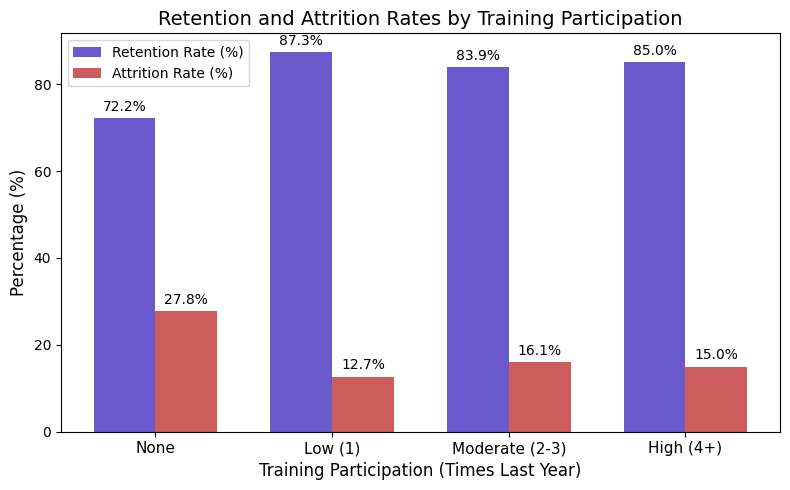

  TrainingParticipation  Total  Retention_Rate_%  Attrition_Rate_%
0                  None     54         72.222222         27.777778
1               Low (1)     71         87.323944         12.676056
2        Moderate (2-3)   1038         83.911368         16.088632
3             High (4+)    307         85.016287         14.983713


In [76]:
import numpy as np

# Investigate the relationship between training participation and retention rates

# We'll use the TrainingTimesLastYear column as a proxy for training participation,
# and Attrition_Flag (1=Left, 0=Stayed) for retention.

# 1. Create categorical bins for training participation for clear summarization
bins = [-1, 0, 1, 3, np.inf]
labels = ['None', 'Low (1)', 'Moderate (2-3)', 'High (4+)']
df['TrainingParticipation'] = pd.cut(df['TrainingTimesLastYear'], bins=bins, labels=labels)

# 2. Calculate retention/attrition rates for each training participation group
training_retention = (
    df.groupby('TrainingParticipation')['Attrition_Flag']
    .agg(
        Total='count',
        Left='sum'
    )
    .reset_index()
)
training_retention['Retention_Rate_%'] = 100 * (1 - training_retention['Left'] / training_retention['Total'])
training_retention['Attrition_Rate_%'] = 100 * (training_retention['Left'] / training_retention['Total'])

# 3. Plot retention and attrition rates by training group (side by side bars)
fig, ax1 = plt.subplots(figsize=(8, 5))
x = np.arange(len(training_retention['TrainingParticipation']))
width = 0.35

rects1 = ax1.bar(
    x - width/2,
    training_retention['Retention_Rate_%'],
    width,
    label='Retention Rate (%)',
    color='slateblue'
)
rects2 = ax1.bar(
    x + width/2,
    training_retention['Attrition_Rate_%'],
    width,
    label='Attrition Rate (%)',
    color='indianred'
)

# Value labels on bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax1.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

# Axes and legend settings
ax1.set_xticks(x)
ax1.set_xticklabels([l.replace('_', '\n') for l in training_retention['TrainingParticipation'].astype(str)], fontsize=11)
ax1.set_ylabel('Percentage (%)', fontsize=12)
ax1.set_xlabel('Training Participation (Times Last Year)', fontsize=12)
ax1.set_title('Retention and Attrition Rates by Training Participation', fontsize=14)
ax1.legend(loc='best')
plt.tight_layout()
plt.show()

# Optionally, display the table as well
print(training_retention[['TrainingParticipation', 'Total', 'Retention_Rate_%', 'Attrition_Rate_%']])


#4.6 Geographic and Commuting Factors גורמים גאוגרפיים ונסיעות

C:\Users\moran\AppData\Local\Temp\ipykernel_23056\1891778176.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df.groupby('DistanceBin')['Attrition_Flag'].agg(['sum', 'count']).rename(columns={'sum': 'Left', 'count': 'Total'})


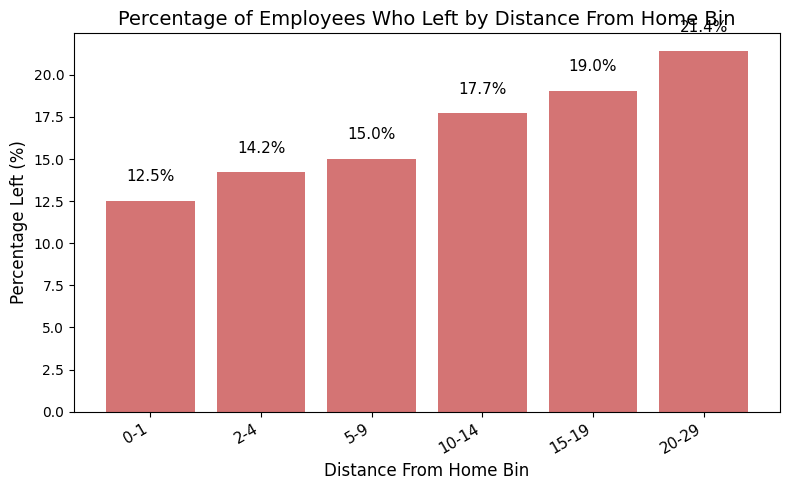

             Left  Total     Left_%
DistanceBin                        
0-1            26    208  12.500000
2-4            51    359  14.206128
5-9            56    373  15.013405
10-14          31    175  17.714286
15-19          24    126  19.047619
20-29          49    229  21.397380


In [84]:
# Show only the percentage of employees who left (Attrition) by DistanceFromHome bins

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df has columns: 'DistanceFromHome' and 'Attrition_Flag'
# Attrition_Flag: 1 = Left, 0 = Stayed

# Define bins for DistanceFromHome (adjust bin edges as needed)
bin_edges = [0, 2, 5, 10, 15, 20, df['DistanceFromHome'].max() + 1]
bin_labels = [f"{int(bin_edges[i])}-{int(bin_edges[i+1])-1}" for i in range(len(bin_edges) - 1)]
df['DistanceBin'] = pd.cut(df['DistanceFromHome'], bins=bin_edges, labels=bin_labels, right=False)

# Calculate percentage of employees who left for each distance bin
bin_counts = df.groupby('DistanceBin')['Attrition_Flag'].agg(['sum', 'count']).rename(columns={'sum': 'Left', 'count': 'Total'})
bin_counts['Left_%'] = np.where(
    bin_counts['Total'] > 0,
    bin_counts['Left'] / bin_counts['Total'] * 100,
    0
)

# Plotting
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bin_counts.index, bin_counts['Left_%'], color='indianred', alpha=0.85)

# Annotate the bars with the percentage values
for i, v in enumerate(bin_counts['Left_%']):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=11)

ax.set_xlabel('Distance From Home Bin', fontsize=12)
ax.set_ylabel('Percentage Left (%)', fontsize=12)
ax.set_title('Percentage of Employees Who Left by Distance From Home Bin', fontsize=14)
ax.set_xticks(range(len(bin_counts.index)))
ax.set_xticklabels([label.replace('_', '\n') for label in bin_counts.index], rotation=30, ha='right', fontsize=11)
plt.tight_layout()
plt.show()

# Optionally, print the table for reference
print(bin_counts[['Left', 'Total', 'Left_%']])


In [85]:

# 4.7 Data-Driven HR Recommendations
# This markdown cell documents actionable HR recommendations based on EDA analyses.

from IPython.display import display, Markdown

display(Markdown(
"""
### 4.7 Data-Driven HR Recommendations

- **Based on the insights from the analysis, suggest actionable strategies to reduce attrition.**
    - Focus on key factors shown to influence attrition in our data, such as low job satisfaction, work-life balance, promotion frequency, and compensation.

- **Identify potential policy changes that could improve employee retention.**
    - Implement targeted retention programs for groups with higher observed attrition (e.g., employees with long commutes or lower satisfaction scores).
    - Introduce flexible work arrangements or hybrid/remote options for employees living far from the office.
    - Promote regular feedback cycles and recognition programs to improve environment satisfaction.

- **Provide recommendations on compensation, work-life balance initiatives, and career growth opportunities.**
    - Regularly review and adjust compensation structures to remain competitive in the market.
    - Offer personalized career development and upskilling programs for employees in roles with higher turnover.
    - Strengthen work-life balance through more flexible schedules, wellness initiatives, and support resources.

*This structured approach will ensure a comprehensive evaluation of the factors influencing employee attrition and enable the development of targeted HR strategies.*
"""
))





### 4.7 Data-Driven HR Recommendations

- **Based on the insights from the analysis, suggest actionable strategies to reduce attrition.**
    - Focus on key factors shown to influence attrition in our data, such as low job satisfaction, work-life balance, promotion frequency, and compensation.

- **Identify potential policy changes that could improve employee retention.**
    - Implement targeted retention programs for groups with higher observed attrition (e.g., employees with long commutes or lower satisfaction scores).
    - Introduce flexible work arrangements or hybrid/remote options for employees living far from the office.
    - Promote regular feedback cycles and recognition programs to improve environment satisfaction.

- **Provide recommendations on compensation, work-life balance initiatives, and career growth opportunities.**
    - Regularly review and adjust compensation structures to remain competitive in the market.
    - Offer personalized career development and upskilling programs for employees in roles with higher turnover.
    - Strengthen work-life balance through more flexible schedules, wellness initiatives, and support resources.

*This structured approach will ensure a comprehensive evaluation of the factors influencing employee attrition and enable the development of targeted HR strategies.*
